## Instalación e imports

In [2]:
import geopandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon

## Crear geometrías de prueba

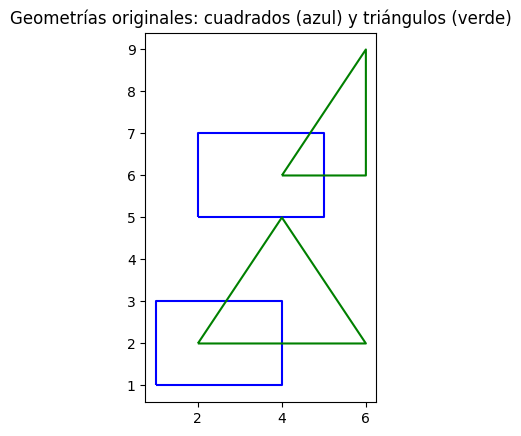

In [3]:
cuadrados = geopandas.GeoSeries([
    Polygon([(1,1), (1,3), (4,3), (4,1)]),
    Polygon([(2,5), (2,7), (5,7), (5,5)])
])
triangulos = geopandas.GeoSeries([
    Polygon([(2,2), (4,5), (6,2)]),
    Polygon([(4,6), (6,9), (6,6)])
])

df_cuadrados = geopandas.GeoDataFrame({'geometry': cuadrados, 'df_cuadrados':[1,2]})
df_triangulos = geopandas.GeoDataFrame({'geometry': triangulos, 'df_triangulos':[1,2]})

ax = df_cuadrados.boundary.plot(color='blue')
df_triangulos.boundary.plot(ax=ax, color='green')
plt.title('Geometrías originales: cuadrados (azul) y triángulos (verde)')
plt.show()

## Las 4 operaciones de conjuntos

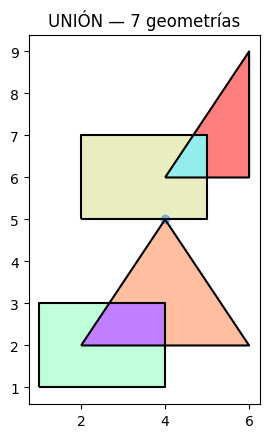

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 1 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


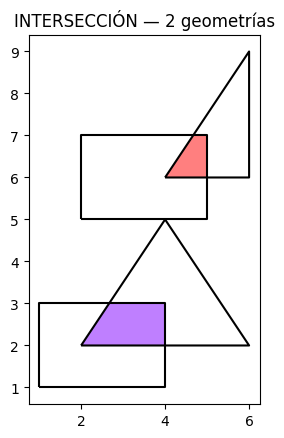

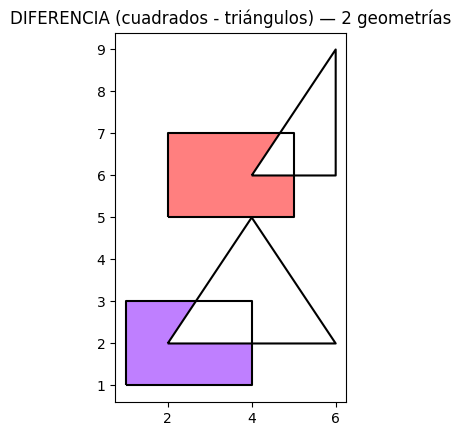

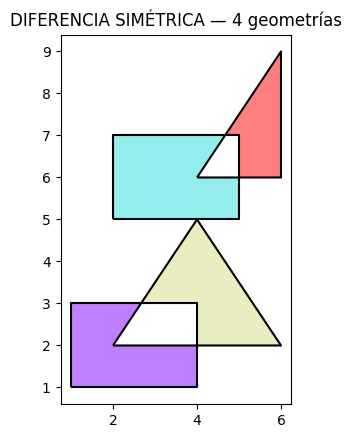

In [4]:
# UNIÓN
union = geopandas.overlay(df_cuadrados, df_triangulos, how='union', keep_geom_type=False)
ax = union.plot(alpha=0.5, cmap='rainbow')
df_cuadrados.boundary.plot(ax=ax, color='black')
df_triangulos.boundary.plot(ax=ax, color='black')
plt.title(f'UNIÓN — {len(union)} geometrías')
plt.show()

# INTERSECCIÓN
interseccion = geopandas.overlay(df_cuadrados, df_triangulos, how='intersection')
ax = interseccion.plot(alpha=0.5, cmap='rainbow')
df_cuadrados.boundary.plot(ax=ax, color='black')
df_triangulos.boundary.plot(ax=ax, color='black')
plt.title(f'INTERSECCIÓN — {len(interseccion)} geometrías')
plt.show()

# DIFERENCIA (cuadrados - triángulos)
diferencia = geopandas.overlay(df_cuadrados, df_triangulos, how='difference')
ax = diferencia.plot(alpha=0.5, cmap='rainbow')
df_cuadrados.boundary.plot(ax=ax, color='black')
df_triangulos.boundary.plot(ax=ax, color='black')
plt.title(f'DIFERENCIA (cuadrados - triángulos) — {len(diferencia)} geometrías')
plt.show()

# DIFERENCIA SIMÉTRICA
diferencia_sim = geopandas.overlay(df_cuadrados, df_triangulos, how='symmetric_difference')
ax = diferencia_sim.plot(alpha=0.5, cmap='rainbow')
df_cuadrados.boundary.plot(ax=ax, color='black')
df_triangulos.boundary.plot(ax=ax, color='black')
plt.title(f'DIFERENCIA SIMÉTRICA — {len(diferencia_sim)} geometrías')
plt.show()

## Ejemplo aplicado: zonas urbanas de México

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: 2. Mapas/mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


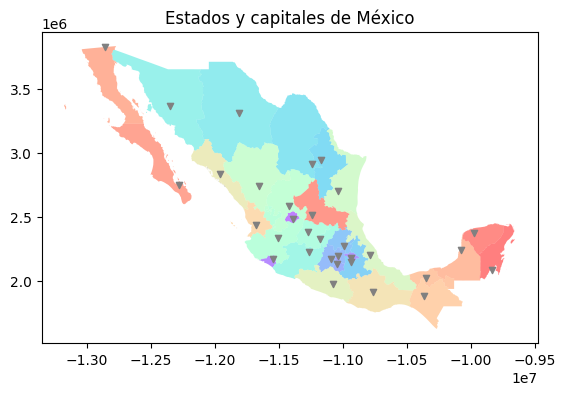

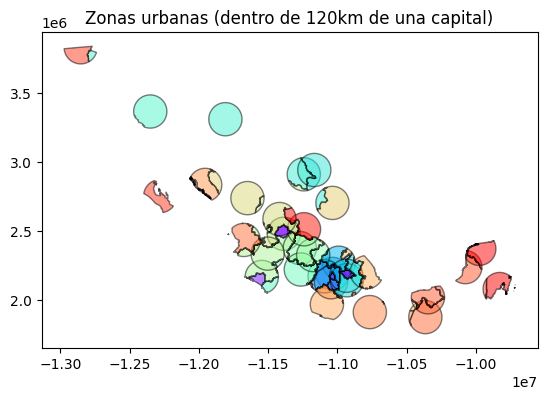

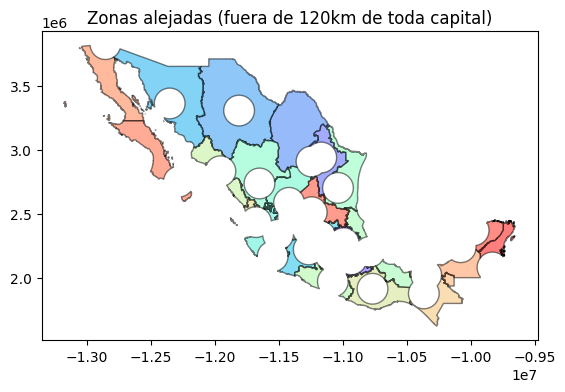

In [5]:
# Cargamos estados y capitales (ajusta el path a donde tengas tus archivos)
estados = geopandas.read_file('2. Mapas/mexican-states.shp')
df = pd.read_csv('2. Mapas/mexican-capitals.csv')
capitales = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.Long, df.Lat))

# Aseguramos mismo CRS, luego convertimos a metros (epsg=3395) para que buffer() de resultados en km reales
capitales = capitales.set_crs(estados.crs)
estados = estados.to_crs(epsg=3395)
capitales = capitales.to_crs(epsg=3395)

# Mapa base: estados + ubicación de capitales
mapa = estados.plot(alpha=0.5, cmap='rainbow')
capitales.plot(ax=mapa, marker='v', color='gray', markersize=20)
plt.title('Estados y capitales de México')
plt.show()

# Creamos un buffer de 120 km alrededor de cada capital
capitales['geometry'] = capitales.buffer(120000)  # 120,000 metros = 120 km

# INTERSECCIÓN: qué parte de cada estado cae dentro de 120km de alguna capital
zonas_urbanas = geopandas.overlay(estados, capitales, how='intersection', keep_geom_type=False)
zonas_urbanas.plot(alpha=0.5, edgecolor='k', cmap='rainbow')
plt.title('Zonas urbanas (dentro de 120km de una capital)')
plt.show()

# DIFERENCIA: el reverso -- zonas MÁS ALEJADAS de cualquier capital
zonas_alejadas = geopandas.overlay(estados, capitales, how='difference', keep_geom_type=False)
zonas_alejadas.plot(alpha=0.5, edgecolor='k', cmap='rainbow')
plt.title('Zonas alejadas (fuera de 120km de toda capital)')
plt.show()

## Fusión de datos: concat, merge, dissolve, sjoin

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: 2. Mapas/mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


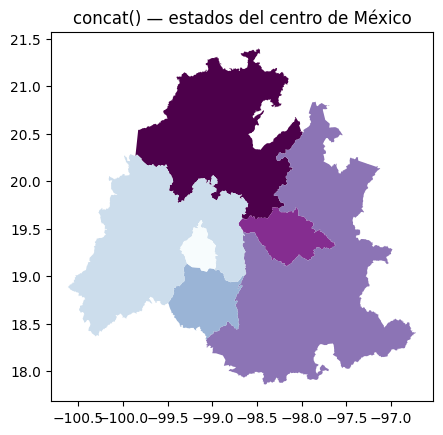

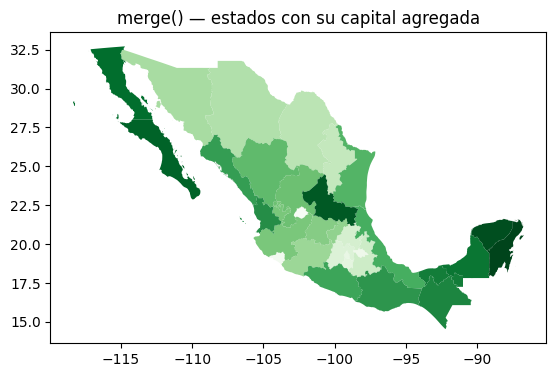

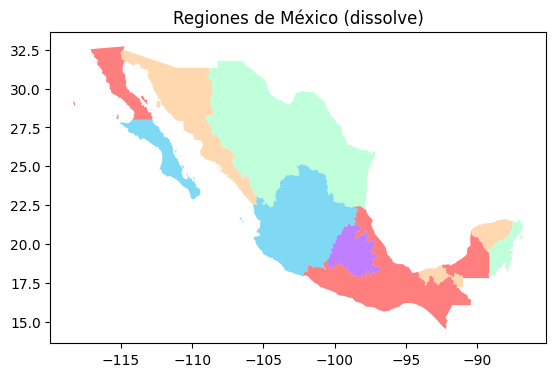

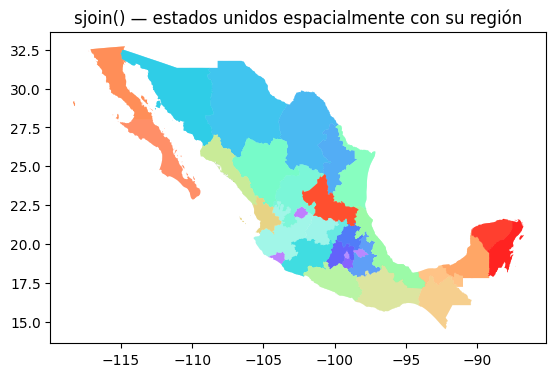

               name   region_left  region_right
0    Aguascalientes  centro oeste  centro oeste
1            Colima  centro oeste  centro oeste
2          Tlaxcala        centro        centro
3  Ciudad de México        centro        centro
4           Morelos        centro        centro


In [11]:
# --- A) ADJUNTAR (concat): apilar varios estados en un solo GeoDataFrame ---
estados = geopandas.read_file('2. Mapas/mexican-states.shp')
estados = estados.loc[:, ['ISO3166-2', 'name', 'geometry']]

hidalgo = estados.iloc[[6]]
tlaxcala = estados.iloc[[2]]
puebla = estados.iloc[[7]]
morelos = estados.iloc[[4]]
mexico = estados.iloc[[5]]
cdmx = estados.iloc[[3]]

mx_centro = pd.concat([hidalgo, tlaxcala, puebla, morelos, mexico, cdmx])
mx_centro.plot(cmap='BuPu_r')
plt.title('concat() — estados del centro de México')
plt.show()

# --- B) UNIÓN POR ATRIBUTOS (merge): agregar la capital a cada estado ---
df_cap = pd.read_csv('2. Mapas/mexican-capitals-by-name.csv')
df_cap = df_cap.loc[:, ['name', 'capital']]

# estados va del lado IZQUIERDO -> el resultado sigue siendo GeoDataFrame
estados_con_capital = estados.merge(df_cap, on='name')
estados_con_capital.plot(cmap='Greens')
plt.title('merge() — estados con su capital agregada')
plt.show()

# --- C) UNIÓN ESPACIAL (sjoin): asignar región según ubicación geográfica ---
estados['region'] = ['centro oeste','centro oeste','centro','centro','centro',
                      'centro','centro','centro','noreste','noreste','noreste',
                      'noroeste','centro oeste','centro oeste','centro oeste',
                      'centro oeste','centro oeste','noreste','noreste','sureste',
                      'sureste','noroeste','sureste','centro oeste','sureste',
                      'noroeste','sureste','sureste','centro oeste','centro oeste',
                      'noroeste','noreste']  # ajusta según el orden real de tu shapefile

# Fusionamos los estados en polígonos de región (uno por región)
regiones = estados.dissolve(by='region')
regiones = regiones.loc[:, 'geometry']
regiones_gdf = geopandas.GeoDataFrame(geopandas.GeoSeries(regiones))

regiones_gdf.plot(alpha=0.5, cmap='rainbow')
plt.title('Regiones de México (dissolve)')
plt.show()

# sjoin: le asigna a cada estado la región con la que se traslapa
estados_por_regiones = geopandas.sjoin(estados, regiones_gdf, how='inner', predicate='intersects')
estados_por_regiones.plot(alpha=0.5, cmap='rainbow')
plt.title('sjoin() — estados unidos espacialmente con su región')
plt.show()

print(estados_por_regiones[['name', 'region_left', 'region_right']].head())

## sjoin_nearest: unir por cercanía

In [8]:
# Ejemplo: para cada estado, encontrar la capital más cercana (aunque no esté "dentro" del estado)
cercania = geopandas.sjoin_nearest(estados, capitales, distance_col='distancia_m')
print(cercania[['name', 'distancia_m']].sort_values('distancia_m').head())

C:\Users\diego\AppData\Local\Temp\ipykernel_32020\4279071731.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:3395

  cercania = geopandas.sjoin_nearest(estados, capitales, distance_col='distancia_m')
c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


                   name   distancia_m
27      Baja California  9.927177e+06
11               Sonora  9.927179e+06
28  Baja California Sur  9.927180e+06
10            Chihuahua  9.927186e+06
21              Sinaloa  9.927186e+06
